In [ ]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import numpy as np
import sys
import shap
import statsmodels.api as sm
import pickle
import json

sys.path.insert(0, "../../../utils")

from modules import *

from sklearn.metrics import  mean_absolute_error, mean_squared_error
import xgboost as xgb
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import KNNImputer
from Model_Validation_Module import *

enc = 'utf-8'

REGION = 'ExtNord'

TARGET = ''

In [4]:
dataframe = pd.read_csv(f'../../../data/{REGION}/CM_{REGION}_Dataset_2015-2024.csv', encoding=enc)

In [5]:
dataframe.sort_values(["dt_prediction", "GID0", "GID1", "GID2", "GID3"], inplace=True)

dataframe['location'] = list(zip(dataframe['GID0'], dataframe['GID1'], dataframe['GID2'], dataframe['GID3']))
dataframe.drop(columns=['GID0', 'GID1', 'GID2', 'GID3', 'year', 'month', 'dt_recorded_cases', 'dt_weather_acc', 'year_biovars', 'year_lc'], inplace=True)
dataframe['dt_prediction'] = pd.to_datetime(dataframe['dt_prediction']).dt.to_period('M')

dataframe = dataframe[['location'] + dataframe.columns.to_list()[:-1]]

In [6]:
dataframe.drop(columns=['Case_UND5', 'Case_OVR5', 'Case_PRGN', 
                      'Sevr_UND5', 'Sevr_OVR5', 'Sevr_PRGN', 'Sevr_TOTAL',
                      'Hosp_UND5', 'Hosp_OVR5', 'Hosp_PRGN', 'Hosp_TOTAL',
                      'Death_UND5', 'Death_OVR5', 'Death_PRGN', 'Death_TOTAL'], inplace=True)

dataframe.rename(columns={'Case_TOTAL': 'cases'}, inplace=True)

In [7]:
rainfall_cols = [col for col in dataframe.columns if 'rainfall' in col]
lst_cols = [col for col in dataframe.columns if 'lst' in col]
bio_cols = [col for col in dataframe.columns if 'bio' in col]
geo_cols = ['distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m']
geo_cols += [f"{col}_std" for col in geo_cols]

round_cols = [rainfall_cols, lst_cols, bio_cols, geo_cols]
round_factor = [4,2,2,2]

In [ ]:
with open(f'saved/CM_{REGION}_bin_ranges{TARGET}.pkl', 'rb') as f:
    bin_ranges = pickle.load(f)

In [9]:
num_of_classes = len(bin_ranges) - 1
print(f'Number of classes: {num_of_classes}')

Number of classes: 9


In [10]:
risk_classes = list(range(0,num_of_classes))
risk_classes

[0, 1, 2, 3, 4, 5, 6, 7, 8]

In [11]:
bins, bounds = pd.cut(x = dataframe.loc[:, 'cases'], bins=bin_ranges, right=False, include_lowest=True, labels=risk_classes, retbins=True, precision=0)

In [12]:
dataframe['case_bin'] = bins

In [13]:
dataset = dataframe.copy()

In [14]:
dataset['case_bin'] = pd.Categorical(dataset['case_bin'])

In [15]:
# bounds = np.concatenate(([0], bounds))
bounds = np.array(bounds, dtype=int)
print(f'Bounds: {bounds}')

Bounds: [   0    1    6   16   32   64  128  256  512 8023]


In [16]:
dataset.sort_values(["dt_prediction", "location"], inplace=True)
dataset.reset_index(drop=True, inplace=True)

In [17]:
dataset

,location,x,y,dt_prediction,month_sin,month_cos,ndvi,ndmi,ndwi,ndbi,...,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,cases,case_bin
0,"(extreme nord, diamare, bogo, balaza)",14.515776,10.786560,2014-10,-0.866,0.5,0.316173,-0.031746,-0.367008,0.031746,...,1377,496,0,144.44,1114,0,97,914,94,5
1,"(extreme nord, diamare, bogo, balda)",14.724237,10.914551,2014-10,-0.866,0.5,0.272376,-0.078135,-0.381671,0.078135,...,1303,489,0,149.02,1078,0,66,1078,7,2
2,"(extreme nord, diamare, bogo, bogo)",14.597860,10.743440,2014-10,-0.866,0.5,0.318198,-0.031092,-0.376078,0.031092,...,1359,489,0,146.88,1124,0,89,891,91,5
3,"(extreme nord, diamare, bogo, borai)",14.606980,10.653607,2014-10,-0.866,0.5,0.315827,-0.054343,-0.400066,0.054343,...,1451,512,0,144.81,1188,0,92,1188,31,3
4,"(extreme nord, diamare, bogo, guinggley)",14.702740,10.792848,2014-10,-0.866,0.5,0.266854,-0.059092,-0.366169,0.059092,...,1343,481,0,145.68,1106,1,93,911,109,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33881,"(extreme nord, mayo-tsanaga, roua, madakonai)",14.023290,10.779370,2024-09,-1.000,0.0,0.557657,0.106765,-0.464755,-0.106765,...,1475,560,0,134.60,1040,1,163,959,155,6
33882,"(extreme nord, mayo-tsanaga, roua, medere)",13.986810,10.689540,2024-09,-1.000,0.0,0.563313,0.120332,-0.467706,-0.120332,...,1490,514,0,127.33,1038,1,173,946,146,6
33883,"(extreme nord, mayo-tsanaga, roua, ndimche)",13.968570,10.827287,2024-09,-1.000,0.0,0.544767,0.119364,-0.448170,-0.119364,...,1468,502,0,129.33,1044,2,175,931,76,5
33884,"(extreme nord, mayo-tsanaga, roua, roua)",13.968570,10.779370,2024-09,-1.000,0.0,0.596169,0.158170,-0.488677,-0.158170,...,1569,569,0,133.83,1146,2,180,801,51,4


In [18]:
X = dataset.select_dtypes(exclude=['object', 'period[M]']).drop(columns=['cases', 'case_bin'])
y = dataset['case_bin']

n_folds = 10
k_fold = StratifiedKFold(n_splits = n_folds, shuffle = True, random_state = 0)

In [19]:
features_to_remove = []

feature_names = X.drop(columns = features_to_remove).columns
print(feature_names.to_list())

print(f"Total Features Used: {len(feature_names)}")

['x', 'y', 'month_sin', 'month_cos', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst', 'lst_day', 'lst_night', 'lst_min_prev_month', 'lst_max_prev_month', 'rainfall', 'rainfall_acc_prev_month', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 'distance_to_coast_std', 'distance_to_river_std', 'slope_mean_1km_std', 'aspect_mean_200m_std', 'elevation_mean_1km_std', 'hillshade_mean_1km_std', 'fs_area_1km_std', 'flow_accu_200m_std', 'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type1', 'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19']
Total Features Used: 66


In [ ]:
with open(f'saved/CM_{REGION}_rfecv_model{TARGET}.pkl', "rb") as f:
    fitted_rfe = pickle.load(f)

In [ ]:
with open(f'saved/CM_{REGION}_gridcv_best_params{TARGET}.json', "r") as f:
    model_params = json.load(f)

In [22]:
fold_counter = 0
y_train_list = []
y_test_list = []
y_train_pred_list = []
y_test_pred_list = []

shap_values_list = []
test_idx_list = []

for train_idx, test_idx in k_fold.split(X, y):
    print(f'Fold: {fold_counter+1}/{n_folds}')

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

    imputer = KNNImputer(n_neighbors=3)
    imputer.fit(X_train_scaled)
    X_train_imputed = pd.DataFrame(imputer.transform(X_train_scaled), columns=X_train.columns, index=X_train.index)
    X_test_imputed = pd.DataFrame(imputer.transform(X_test_scaled), columns=X_test.columns, index=X_test.index)

    X_train_imputed = pd.DataFrame(scaler.inverse_transform(X_train_imputed), columns=X_train.columns, index=X_train.index)
    X_test_imputed = pd.DataFrame(scaler.inverse_transform(X_test_imputed), columns=X_test.columns, index=X_test.index)

    X_train_imputed = round_columns(X_train_imputed, round_cols, round_factor)
    X_test_imputed = round_columns(X_test_imputed, round_cols, round_factor)

    X_train_rfe = pd.DataFrame(fitted_rfe.transform(X_train_imputed), columns = X.columns[fitted_rfe.support_], index=X_train.index)
    X_test_rfe = pd.DataFrame(fitted_rfe.transform(X_test_imputed), columns = X.columns[fitted_rfe.support_], index=X_test.index)

    model = xgb.XGBRegressor(**model_params)   
    fitted_model = model.fit(X_train_rfe, y_train, verbose=False)

    y_train_pred = fitted_model.predict(X_train_rfe)
    y_test_pred = fitted_model.predict(X_test_rfe)

    y_train_list.append(y_train)
    y_test_list.append(y_test)
    y_train_pred_list.append(y_train_pred)
    y_test_pred_list.append(y_test_pred)

    # SHAP TreeExplainer for XGBRegressor
    explainer = shap.TreeExplainer(fitted_model)
    shap_values = explainer.shap_values(X_test_rfe)
    shap_values_list.append(shap_values)
    test_idx_list.append(test_idx)

    fold_counter += 1

Fold: 1/10
Fold: 2/10
Fold: 3/10
Fold: 4/10
Fold: 5/10
Fold: 6/10
Fold: 7/10
Fold: 8/10
Fold: 9/10
Fold: 10/10


In [23]:
y_train_true = np.concatenate(y_train_list, axis=0)
y_test_true = np.concatenate(y_test_list, axis=0)

y_train_pred = np.concatenate(y_train_pred_list, axis = 0)
y_test_pred = np.concatenate(y_test_pred_list, axis = 0)

y_train_pred = np.clip(np.round(y_train_pred), 0, num_of_classes-1).astype(int)
y_test_pred = np.clip(np.round(y_test_pred), 0, num_of_classes-1).astype(int)

In [24]:
results_train = pd.DataFrame({'actual': y_train_true,'prediction': y_train_pred})
results_test = pd.DataFrame({'actual': y_test_true,'prediction': y_test_pred})

results_test['dt_prediction'] = dataset.loc[results_test.index, 'dt_prediction']
results_test['dt_temp'] = results_test['dt_prediction']+3

results_train.reset_index(drop=True, inplace=True)
results_test.reset_index(drop=True, inplace=True)

In [25]:
metrics(results_train, results_test, threshold=1)

MAE on train set: 0.4000
MSE on train set: 0.4564
min prediction: 0
max prediction: 8

MAE on test set: 0.6415
MSE on test set: 0.9021
Error <= 1: 91.15 %
min prediction: 0
max prediction: 8


In [26]:
plot_error_by_group(
    df=results_test,
    y_true_col='actual',
    y_pred_col='prediction',
    group_by='class',
    metric='mae',
    title='MAE per Risk Class'
)

In [27]:
plot_hist_plotly(results_test['actual'], results_test['prediction'])

In [28]:
test_set = np.concatenate(test_idx_list)
shap_values = np.vstack(shap_values_list)
X_test = pd.DataFrame(X.iloc[test_set],columns=X.columns[fitted_rfe.support_])

In [29]:
tree_shap_values_df = pd.DataFrame(shap_values, columns=X.columns[fitted_rfe.support_], index=test_set)

sorted_mean_abs_values_idx = tree_shap_values_df.abs().mean().sort_values(ascending=False).index

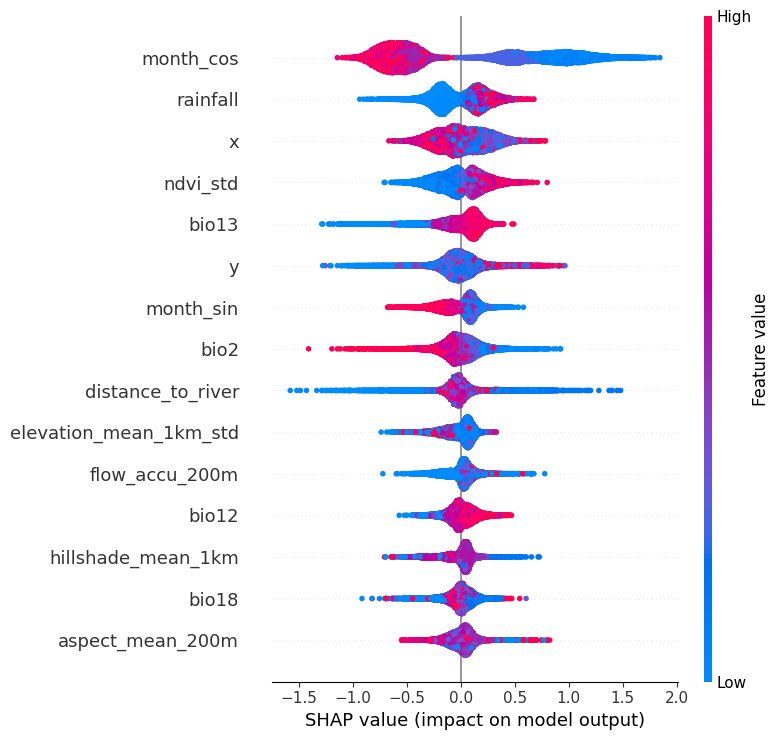

In [30]:
shap.summary_plot(shap_values, X_test, max_display=15)

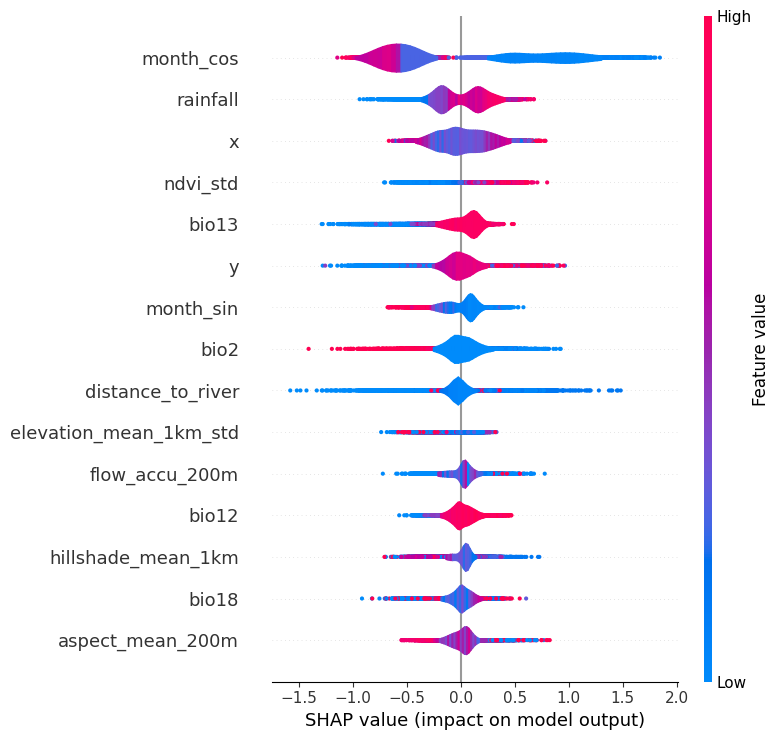

In [31]:
shap.summary_plot(shap_values, X_test, plot_type='violin', max_display=15)

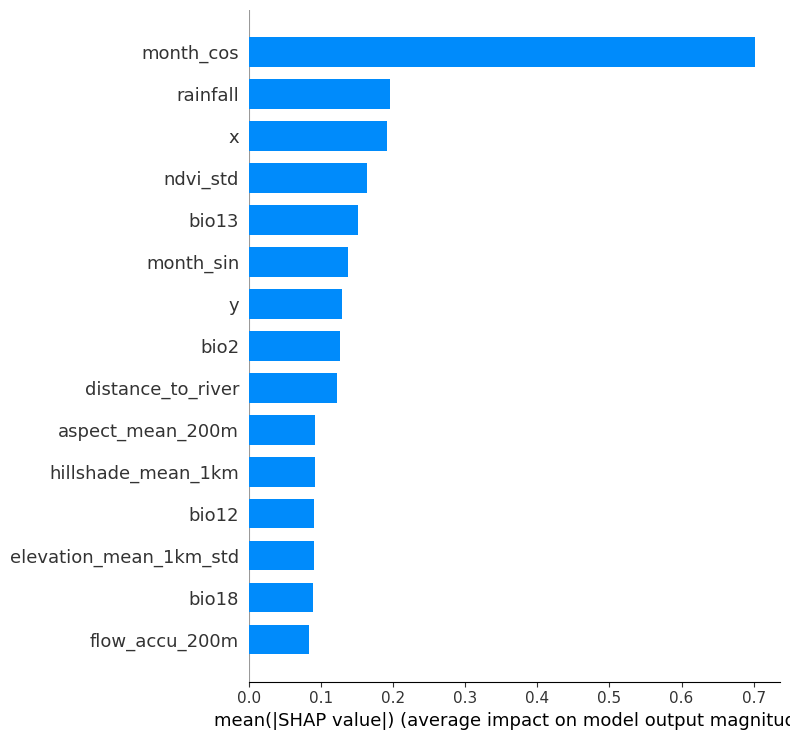

In [49]:
shap.summary_plot(shap_values, X_test, plot_type='bar', max_display=15)

In [32]:
shap_lim = (-1.5, 2)
lowess_it = 3
lowess_frac = 0.5
shap_alpha = 0.5

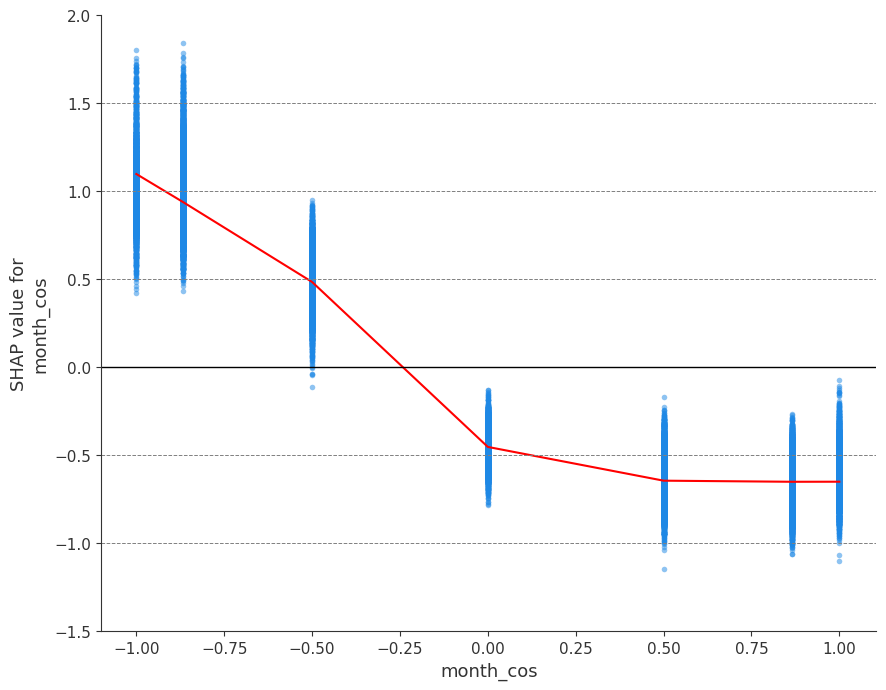

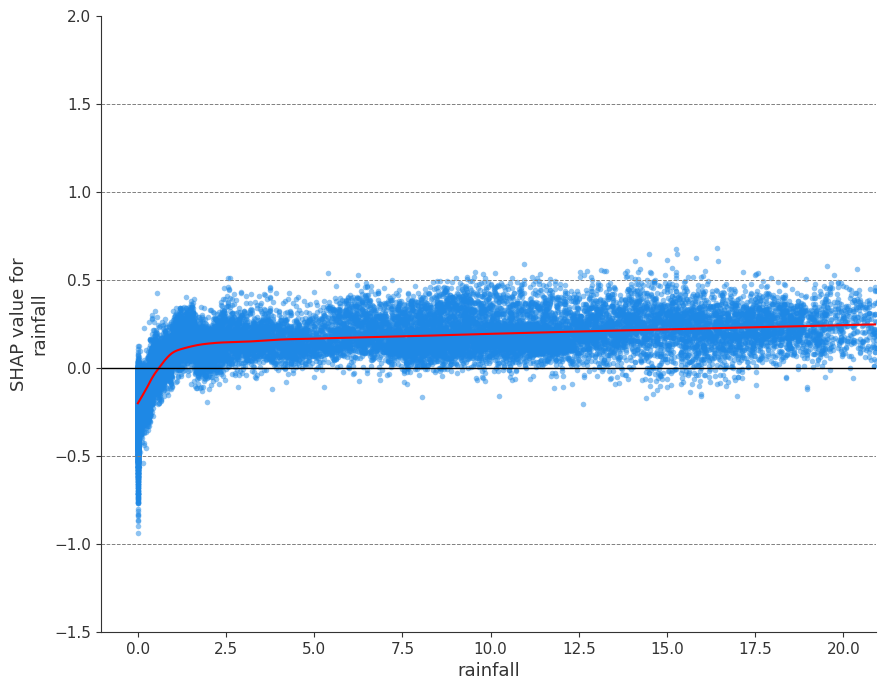

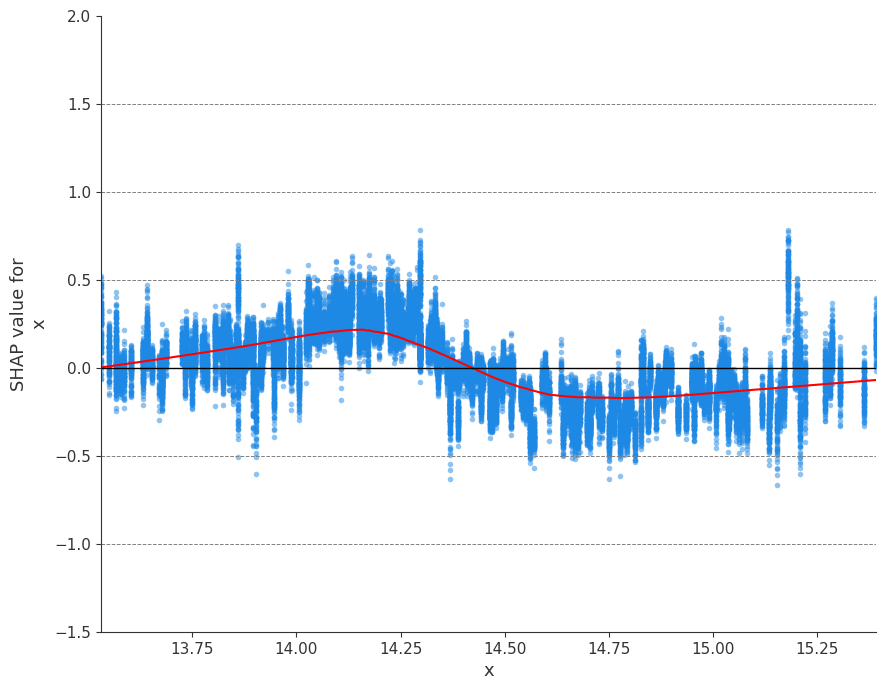

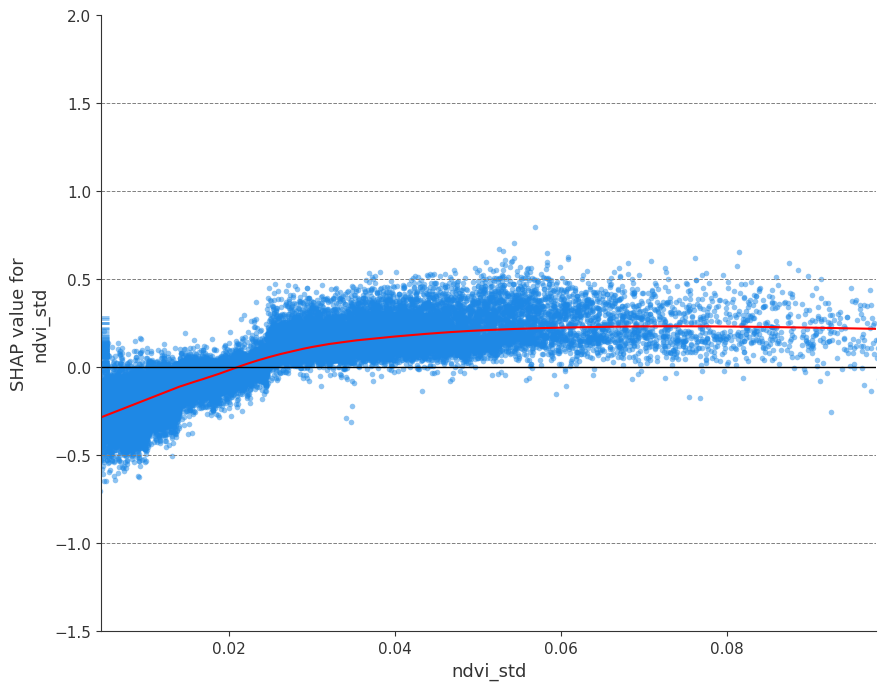

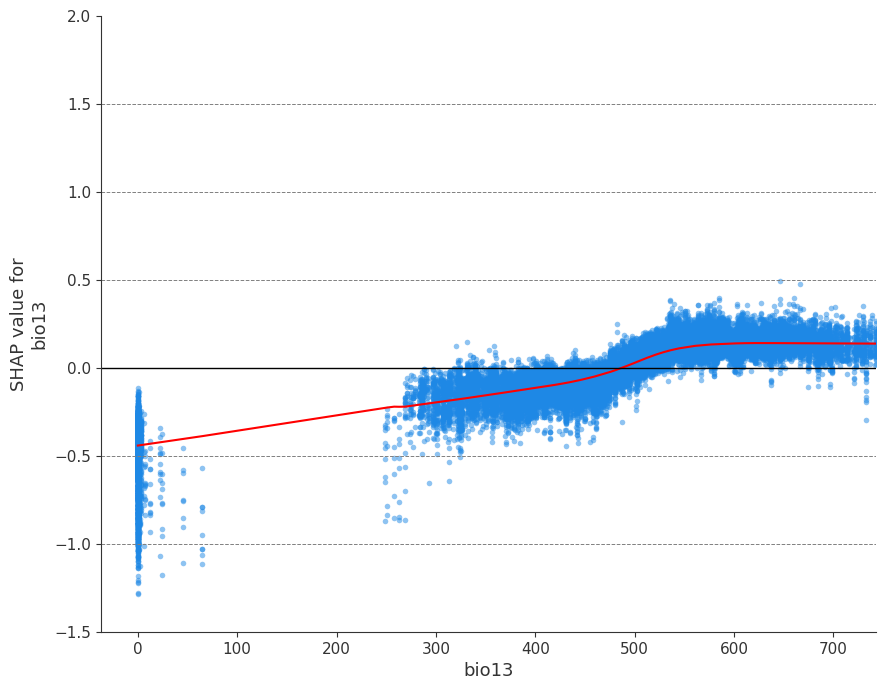

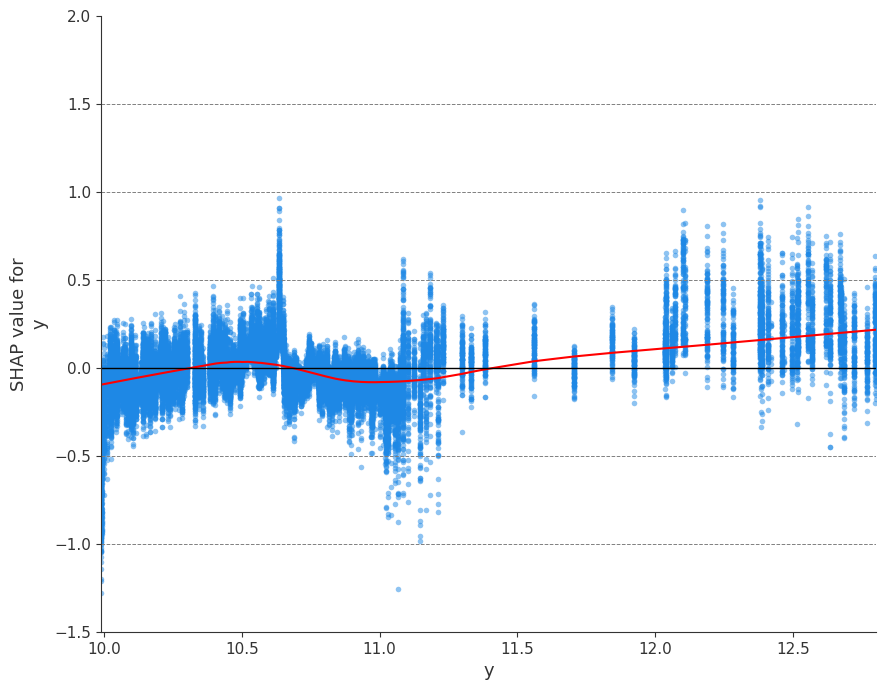

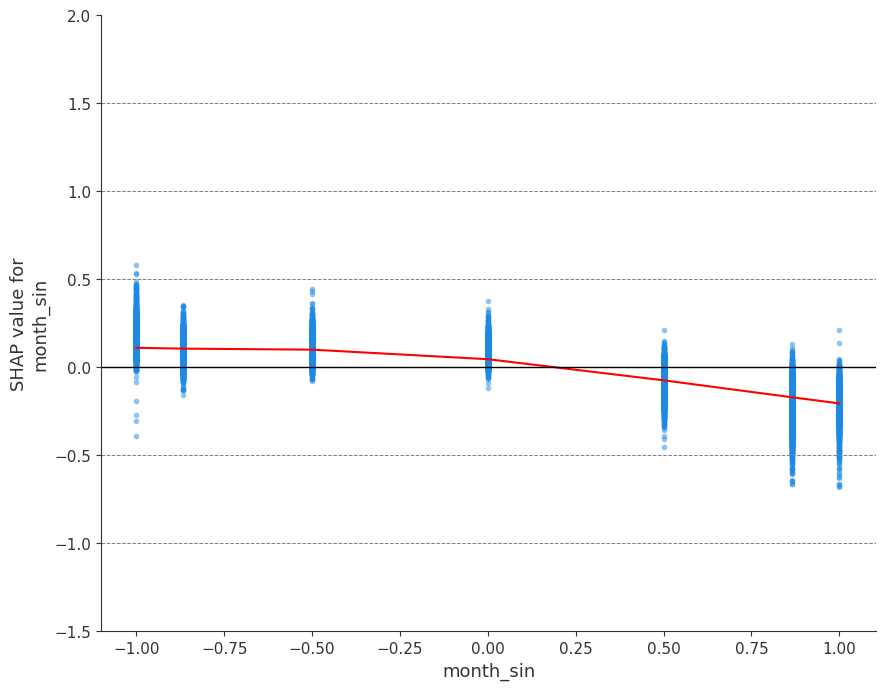

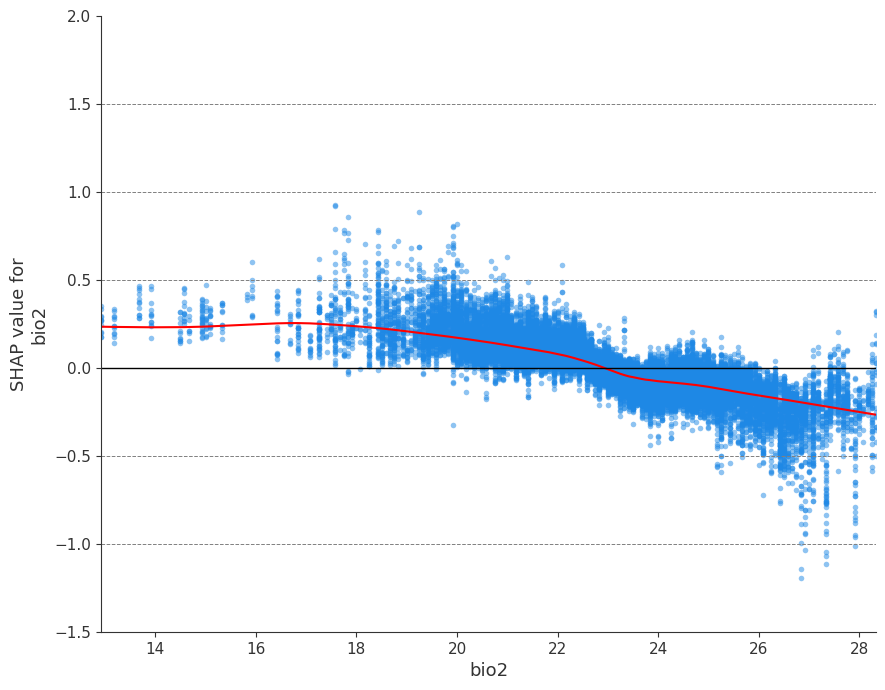

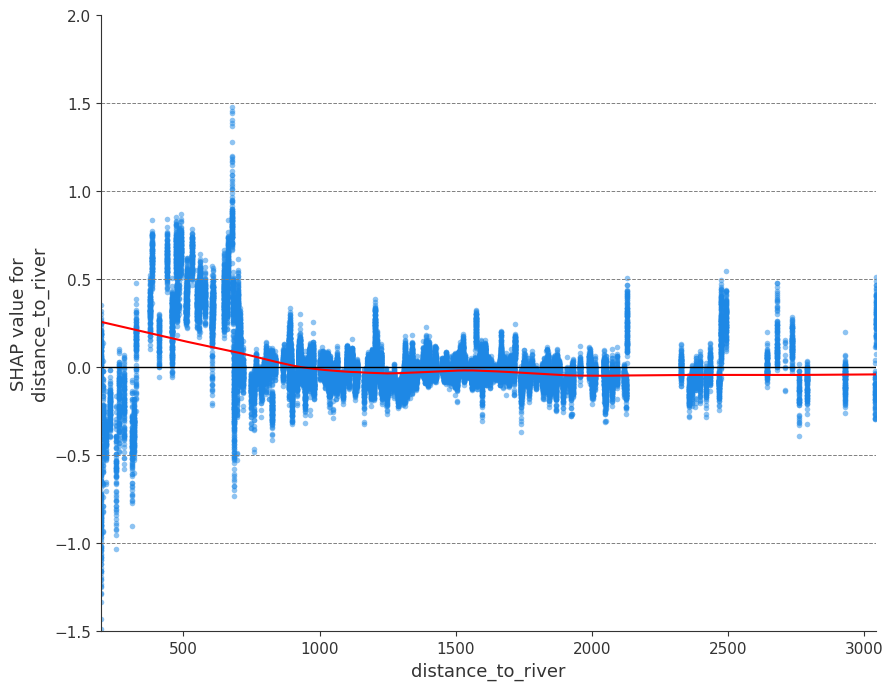

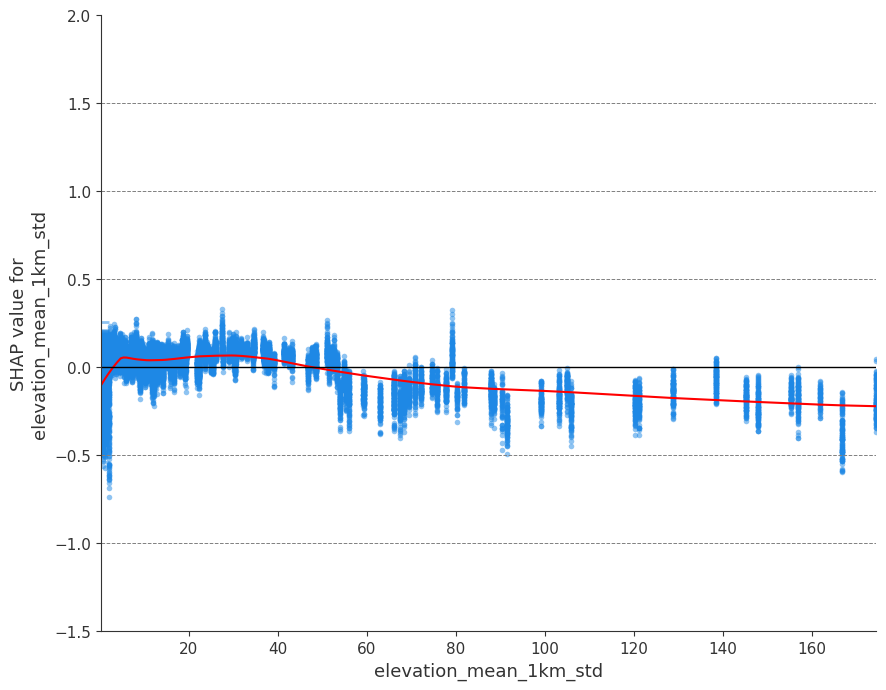

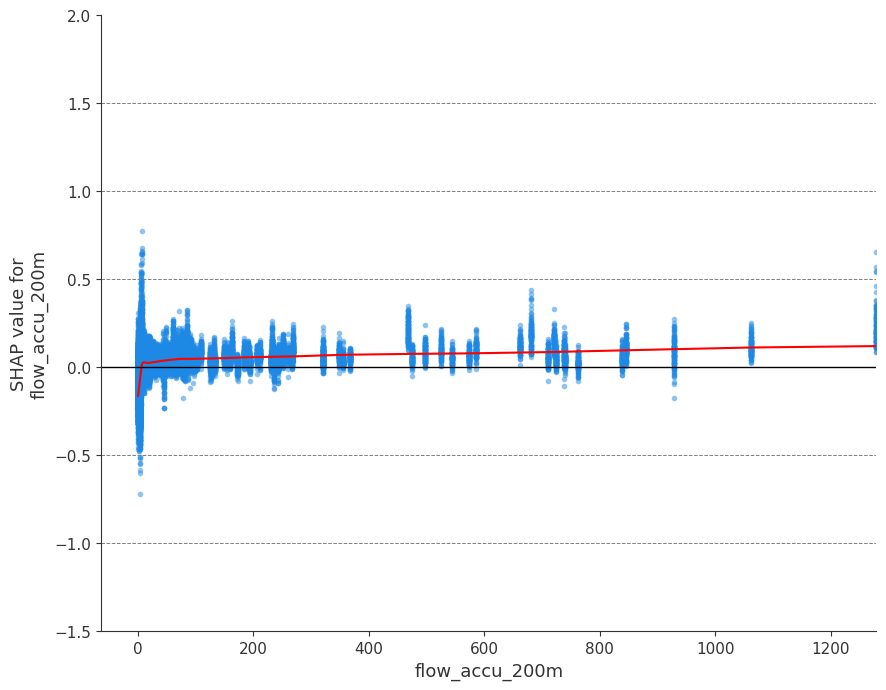

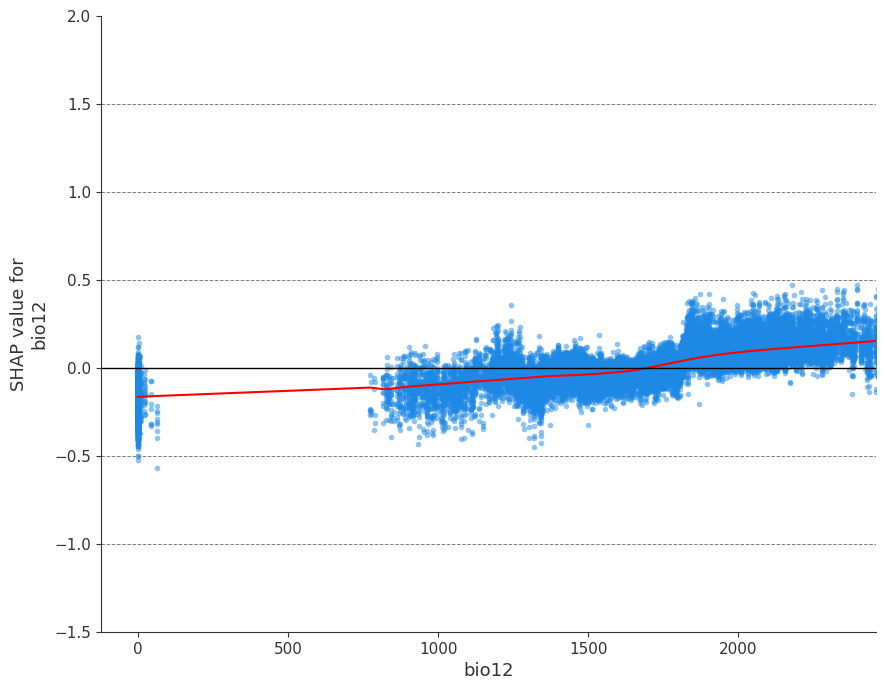

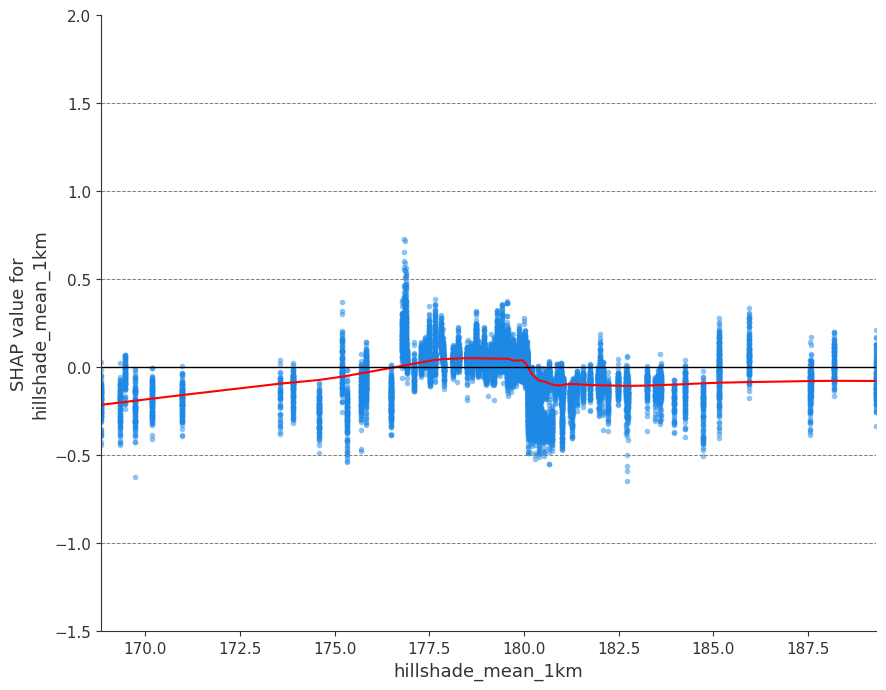

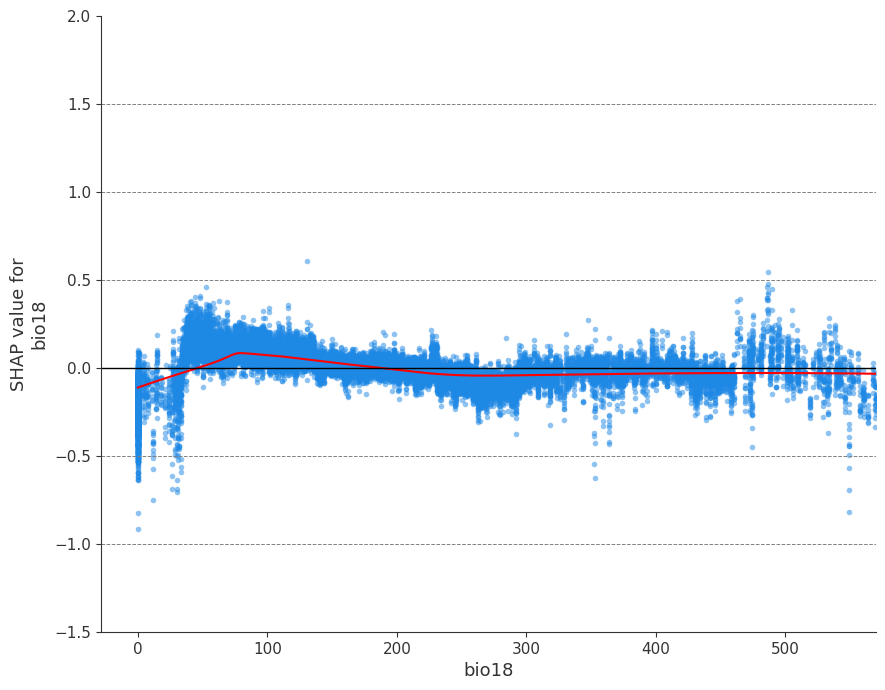

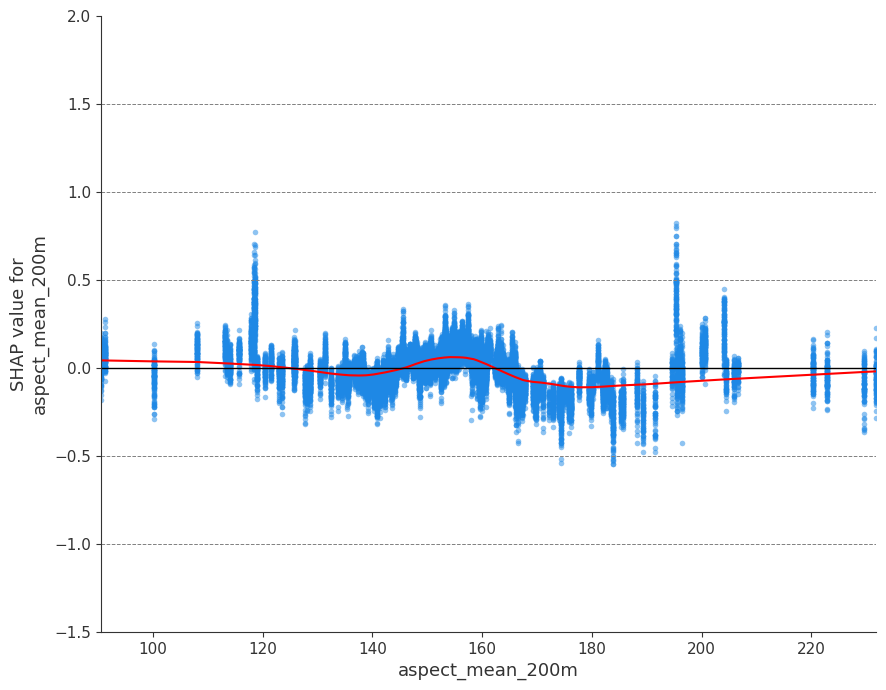

In [33]:
for ft in sorted_mean_abs_values_idx[:15]:
    feature = ft
    shap_values = shap_values
    data = X_test
    feature_names = X_test.columns

    idx = np.where(X_test.columns==feature)[0][0]
    x = X_test.iloc[:,idx]
    y_sv = shap_values[:,idx]
    lowess = sm.nonparametric.lowess(y_sv, x, it=lowess_it,frac=lowess_frac)
    fig,ax = plt.subplots(figsize=(10, 8))
    # ax.set_facecolor('lightgrey')
    ax.plot(*list(zip(*lowess)), color="red", lw=1.5)
    ax.axhline(y=1.5, color='grey', linestyle='--', lw=0.7)
    ax.axhline(y=1, color='grey', linestyle='--', lw=0.7)
    ax.axhline(y=0.5, color='grey', linestyle='--', lw=0.7)
    ax.axhline(y=0, color='black', linestyle='-', lw=1)
    ax.axhline(y=-0.5, color='grey', linestyle='--', lw=0.7)
    ax.axhline(y=-1, color='grey', linestyle='--', lw=0.7)
    ax.axhline(y=-1.5, color='grey', linestyle='--', lw=0.7)
    
    ax.set_ylim(shap_lim)
    
    shap.dependence_plot(ind = feature, shap_values = shap_values, features = X_test, feature_names = feature_names, 
                         interaction_index=None, xmin="percentile(1)", xmax="percentile(99)", alpha=shap_alpha, ax = ax)